In [25]:
from pathlib import Path
from platform import python_version
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")
logger.info("Interpreting with python {}".format(python_version()))
# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"
logger.info(f"Module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
    logger.info("Markov Module path inserted into system path, ready to use")
else:
    logger.info("Markov Module path already inserted into system paths")


def _deep_reload(module_name):
    module = sys.modules[module_name]
    importlib.reload(module)
    for name, submod in module.__dict__.items():
        if hasattr(submod, '__name__') and submod.__name__.startswith(module_name + '.'):
            _deep_reload(submod.__name__)

# Temp solution to load as module
try:
    from model import markov_chain as mc
    from model import probabilistic_analysis as psa
    from model import visualization  # noqa: F401
    from model import constants
    from model import utils
    from model import defined_types
    
    # Force to update module
    _deep_reload('model')
    logger.info("Module reloaded")
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: Interpreting with python 3.13.11
INFO: Module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Markov Module path already inserted into system paths
INFO: Module reloaded


In [26]:
import numpy as np


logger.info(
    """\n
    Final Markov Model Structure
    Scenario Childhood (2 - 12 years old)

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
      
      Note:
      This model considers joint bleeds worsen the joints status (pettersson score), but not yet considers the relationship
      between joint damage and number of annual bleeding rate the patients experiences.
      Indeed several articles note that when a joint has been considered as a target joint, 
      there are more chance of repetitive hemarthrosis on that joint.
      So i suggest it will be a better simulation if the ABR some how be calculated dependent to arthropathy progression.
      This approach makes on-demand cheeper for short term and more expensive on long runs. 
      Also the patients overall simulated QALY and COSTs will be effected.
      This suggestion will not be implemented in this model and only proposed for further investigation.
"""
)

# INPUTS
sobol_sample_size = constants.BASE_SOBOL_SAMPLE_SIZE
n_cycles = constants.PRIMARY_CYCLE_COUNT
ssp = constants.PEDIATRIC_STARTING_POINT  # simulation starting point
estate = constants.START_STATE  # entrance state
stats = constants.STATES

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {sobol_sample_size}
    - Simulation steps: {n_cycles} ({n_cycles / constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp / constants.WOY} YO)
    """
)

chains = []
chain_main = mc.Chain(
    name="main",
    states=stats,
    matrix=np.eye(N=len(stats), M=len(stats), dtype=np.float64),
)
chains.append(chain_main)

INFO: 

    Final Markov Model Structure
    Scenario Childhood (2 - 12 years old)

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
      
      Note:
      This model considers joint

INFO: Sampling ABR values took 0.32 seconds
INFO: Generated data length: On-demand -> 3840, Prophylaxis -> 3456


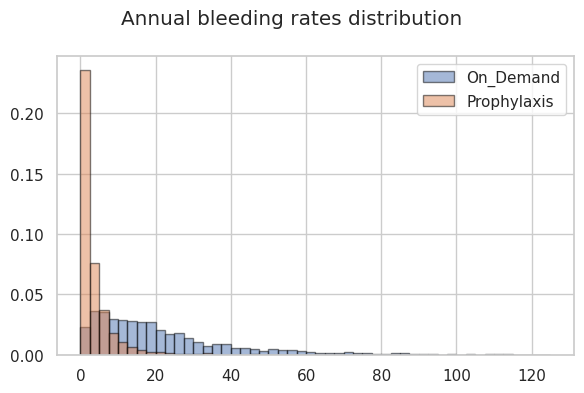

In [27]:
# Short term simulation
from model import defined_types
from time import time
import matplotlib.pyplot as plt
import seaborn as sns


start = time()
# Note: For the sake of statistical comparison n_samples should be in same size over different population in each treatment arms
on_demand_sampled_abr = psa.sample_population_abrs(
    treatment=defined_types.Treatment.ON_DEMAND,
    n_samples=sobol_sample_size,
    visualize=False,
)
prophylaxis_sampled_abr = psa.sample_population_abrs(
    treatment=defined_types.Treatment.PROPHYLAXIS,
    n_samples=sobol_sample_size,
    visualize=False,
)
exc_time = round((time() - start), 2)
logger.info(f"Sampling ABR values took {exc_time} seconds")
logger.info(
    f"Generated data length: On-demand -> {len(on_demand_sampled_abr)}, Prophylaxis -> {len(prophylaxis_sampled_abr)}"
)
if len(on_demand_sampled_abr) != len(prophylaxis_sampled_abr):
    logger.warning(
        "Sample size for treatment arms aren't same, probably caused by different inputs for sobol sampler method."
    )

# Drawing population ABR distribution
plt.figure(figsize=(6, 4))
plt.suptitle("Annual bleeding rates distribution")
on_demand_hist = plt.hist(
    on_demand_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="On_Demand",
)
prophylaxis_hist = plt.hist(
    prophylaxis_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Prophylaxis",
)
plt.legend()
plt.tight_layout()

# TODO:
logger.warning(
    "Dataset for sampling ABR values got update, make sure other model constants have been updated as well."
)

INFO: Patients average weight: 26.19 kg


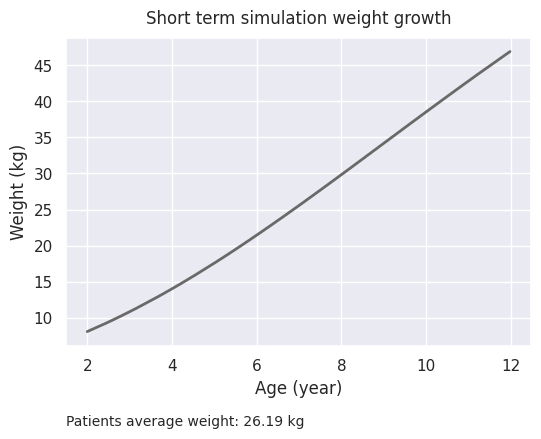

In [28]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(n_cycles)]
pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth graph
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color="dimgray", linestyle="-", linewidth=2)
text = ax.set_title("Short term simulation weight growth", pad=10)
bottom_paragraph = ax.text(
    1.5, -5, f"Patients average weight: {round(average_weight, 2)} kg", fontsize=10
)
y_text = ax.set_ylabel("Weight (kg)")
x_text = ax.set_xlabel("Age (year)")

In [29]:
import model.markov_chain


# Defining markov chains instance
markov = mc.HemophiliaMarkovChains(
    chains=chains,
    entrance="Healthy",
    entrance_chain="main",
    steps=n_cycles,
    conditions=None,
    dead_state="Death",
    original_rate_per_1000=constants.CRUDE_MORTALITY_RATE * 1000,
    mortality_func=constants.get_mortality_rate,
)
logger.info(f"Starting simulations for {n_cycles} steps (weeks)")
# Defining markov models single simulation arguments array
on_demand_hemophilia_inputs = [
    defined_types.HemophiliaInput(
        treatment=defined_types.Treatment.ON_DEMAND,
        abr=abr,
        ajbr=None,
        wbr=None,
        webr=None,
        wjbr=None,
    )
    for abr in on_demand_sampled_abr
]
prophylaxis_hemophilia_inputs = [
    defined_types.HemophiliaInput(
        treatment=defined_types.Treatment.PROPHYLAXIS,
        abr=abr,
        ajbr=None,
        wbr=None,
        webr=None,
        wjbr=None,
    )
    for abr in prophylaxis_sampled_abr
]
# Running and storing simulation results
on_demand_results = model.markov_chain.parallelize_markov_chain(
    simulation_name="on_demand",
    worker_inputs=on_demand_hemophilia_inputs,
    worker_func=psa.worker_function,
    markov_chain=markov,
)
prophylaxis_results = model.markov_chain.parallelize_markov_chain(
    simulation_name="prophylaxis",
    worker_inputs=prophylaxis_hemophilia_inputs,
    worker_func=psa.worker_function,
    markov_chain=markov,
)

INFO: Starting simulations for 520 steps (weeks)


In [30]:
# Unwrap input outputs from markov model simulation results
on_demand_inputs, on_demand_outputs = on_demand_results
prophylaxis_inputs, prophylaxis_outputs = prophylaxis_results

In [31]:
# Convert to numpy arrays for easier handling
on_demand_sampled_abr = np.array(on_demand_sampled_abr)
prophylaxis_sampled_abr = np.array(prophylaxis_sampled_abr)

# Forcing sampled array between treatment arms to be same.
if len(on_demand_sampled_abr) != len(prophylaxis_sampled_abr):
    logger.warning("Sample size mismatch between treatment arms...")

    if len(on_demand_sampled_abr) > len(prophylaxis_sampled_abr):
        longer = on_demand_sampled_abr
        shorter_len = len(prophylaxis_sampled_abr)
        arm_name = "On demand"
    else:
        longer = prophylaxis_sampled_abr
        shorter_len = len(on_demand_sampled_abr)
        arm_name = "Prophylaxis"

    # Randomly subsample the longer array (without replacement)
    indices = np.random.choice(len(longer), size=shorter_len, replace=False)
    subsampled = longer[indices]

    # Assign back
    if arm_name == "On demand":
        on_demand_sampled_abr = subsampled
    else:
        prophylaxis_sampled_abr = subsampled

    logger.warning(f"{arm_name} randomly subsampled to match length {shorter_len}.")
else:
    logger.info("Sample sizes already match.")

SAMPLE_SIZE = len(on_demand_sampled_abr)
logger.info(f"{SAMPLE_SIZE:,} data generated to work with")

cols = list(psa.HemophiliaOutput.model_fields.keys())
cols.insert(0, "regimes")
cols.insert(1, "input_abr")

for key in ["arthropathy", "is_dead", "weights", "mean_weight", "person_year"]:
    cols.append(key)

logger.info("Dataframe Columns: \n {}".format(cols).replace(",", ",\n"))

INFO: 3,456 data generated to work with
INFO: Dataframe Columns: 
 ['regimes',
 'input_abr',
 'initial_state',
 'final_state',
 'steps',
 'path',
 'factor_consumption',
 'factor_costs',
 'annual_factor_consumption',
 'annual_factor_costs',
 'hemarthrosis',
 'qaly',
 'abr',
 'pettersson_score',
 'arthropathy',
 'is_dead',
 'weights',
 'mean_weight',
 'person_year']


In [32]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


def to_stage(pettersson_score_sequence: list[int | float] | np.ndarray):
    if isinstance(pettersson_score_sequence, list):
        pettersson_score_sequence = np.array(pettersson_score_sequence)
    if len(pettersson_score_sequence.shape) > 1:
        raise ValueError(
            f"Pettersson score array should be 1-D, shape: {pettersson_score_sequence.shape}"
        )
    if np.all(pettersson_score_sequence == 0):
        return "healthy"
    max_score = pettersson_score_sequence.max()
    if max_score < 0:
        raise ValueError("Invalid pettersson score")
    if max_score > 28:
        return "severe"
    elif max_score > 5:
        return "moderate"
    elif max_score <= 5:
        return "mild"
    else:
        raise ValueError(f"No stage defined for pettersson score: {max_score}")


start = time()
on_demand_df = pd.DataFrame(
    columns=cols,
    data={
        "regimes": "on_demand",
        "initial_state": [op.initial_state for op in on_demand_outputs],
        "final_state": [op.final_state for op in on_demand_outputs],
        "steps": [op.steps for op in on_demand_outputs],
        "input_abr": [op["abr"] for op in on_demand_inputs],
        "abr": [op.abr for op in on_demand_outputs],
        "hemarthrosis": [op.hemarthrosis for op in on_demand_outputs],
        "factor_consumption": [op.factor_consumption for op in on_demand_outputs],
        "qaly": [op.qaly for op in on_demand_outputs],
        "factor_costs": [op.factor_costs for op in on_demand_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in on_demand_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in on_demand_outputs],
        "pettersson_score": [op.pettersson_score for op in on_demand_outputs],
        "is_dead": [True if "Death" in op.path else False for op in on_demand_outputs],
        "path": [op.path for op in on_demand_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in on_demand_outputs],
    },
)

# ---- Dependent columns assignment ----
mean_weight = lambda x: round(np.array(x).mean(), 2)  # noqa: E731
person_year = lambda x: round(len(x) / constants.WOY, 2)  # noqa: E731

on_demand_df["mean_weight"] = on_demand_df["weights"].apply(mean_weight)
on_demand_df["person_year"] = on_demand_df["weights"].apply(person_year)
on_demand_df["lifetime_bleeds"] = on_demand_df["abr"] * on_demand_df["person_year"]
exc_time = round((time() - start), 2)
logger.info(f"Loading on_demand data with pandas took {exc_time} seconds")

start = time()
prophylaxis_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "input_abr": [op["abr"] for op in prophylaxis_inputs],
        "initial_state": [op.initial_state for op in prophylaxis_outputs],
        "final_state": [op.final_state for op in prophylaxis_outputs],
        "steps": [op.steps for op in prophylaxis_outputs],
        "abr": [op.abr for op in prophylaxis_outputs],
        "hemarthrosis": [op.hemarthrosis for op in prophylaxis_outputs],
        "factor_consumption": [op.factor_consumption for op in prophylaxis_outputs],
        "qaly": [op.qaly for op in prophylaxis_outputs],
        "factor_costs": [op.factor_costs for op in prophylaxis_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in prophylaxis_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "pettersson_score": [op.pettersson_score for op in prophylaxis_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in prophylaxis_outputs],
        "is_dead": [
            True if "Death" in op.path else False for op in prophylaxis_outputs
        ],
        "path": [op.path for op in prophylaxis_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in prophylaxis_outputs],
    },
    columns=cols,
)
prophylaxis_df["mean_weight"] = prophylaxis_df["weights"].apply(mean_weight)
prophylaxis_df["person_year"] = prophylaxis_df["weights"].apply(person_year)
prophylaxis_df["lifetime_bleeds"] = (
    prophylaxis_df["abr"] * prophylaxis_df["person_year"]
)
exc_time = round((time() - start), 2)
logger.info(f"loading prophylaxis data with pandas took {exc_time} seconds")

df_merged = pd.concat([on_demand_df, prophylaxis_df])

# NOTE:
# revise mean_weight to use peron_year instead of constant value
# ---- Preprocessing ----
unnecessary_columns = ["initial_state", "steps", "path", "weights", "pettersson_score"]
df = df_merged.drop(columns=unnecessary_columns)
df = df.apply(lambda x: round(x, 2) if pd.api.types.is_numeric_dtype(x) else x)
df.sample(n=5).head()

INFO: Loading on_demand data with pandas took 0.97 seconds
INFO: loading prophylaxis data with pandas took 0.9 seconds


,regimes,input_abr,final_state,factor_consumption,factor_costs,annual_factor_consumption,annual_factor_costs,hemarthrosis,qaly,abr,arthropathy,is_dead,mean_weight,person_year,lifetime_bleeds
1583,on_demand,2.86,Healthy,52181.00,3.026498e+09,5218.10,3.026498e+08,2.9,8.54,2.7,mild,False,26.19,10.00,27.00
2037,prophylaxis,0.99,Healthy,1036945.00,6.014281e+10,103694.50,6.014281e+09,0.8,9.00,0.8,mild,False,26.19,10.00,8.00
405,prophylaxis,1.53,Healthy,1039909.00,6.031472e+10,103990.90,6.031472e+09,1.0,8.90,1.0,mild,False,26.19,10.00,10.00
144,prophylaxis,0.47,Death,193787.25,1.123966e+10,19378.72,1.123966e+09,0.2,3.29,0.2,healthy,True,13.62,3.65,0.73
1051,prophylaxis,0.00,Healthy,1024176.00,5.940221e+10,102417.60,5.940221e+09,0.0,9.15,0.0,healthy,False,26.19,10.00,0.00


In [33]:
f2 = lambda x: round(x, 2)  # noqa: E731
df_alive = df[df.final_state != "Death"]
abr_absolute_difference = np.abs(df_alive["abr"] - df_alive["input_abr"])
# Sums
logger.info(
    f"""
    Mean absolute differences of simulated annual bleeding rate vs model input ABR values: {f2(abr_absolute_difference.mean())}, ({f2(abr_absolute_difference.std())})
    """
)

INFO: 
    Mean absolute differences of simulated annual bleeding rate vs model input ABR values: 0.86, (1.49)
    


In [34]:
# TODO: Visualize model generated transition matrix, or store them as csv files

# TODO:
#  PSA for percentage of joint hemorrhages from total annual bleeding rate [_]
#  PSA for factor dose used for treating hemorrhages [_]

In [35]:
SIMULATED_YEARS = int(n_cycles / constants.WOY)
# Converts cumulative results to annual value
per_year = lambda x: x / SIMULATED_YEARS  # noqa: E731
to_billion = lambda x: x / 1_000_000_000  # noqa: E731

MORT_RATE_OD = on_demand_df.is_dead.mean() * 100
MORT_RATE_PRO = prophylaxis_df.is_dead.mean() * 100
# Relative mortality reduction
RRR = (MORT_RATE_OD - MORT_RATE_PRO) / MORT_RATE_OD * 100
PREVENTED_DEATH = on_demand_df.is_dead.sum() - prophylaxis_df.is_dead.sum()
PREVENTED_DEATH_PER_1000P = PREVENTED_DEATH / SAMPLE_SIZE * 1000

ANNUAL_BLEED_PREVENTED = round(on_demand_df.abr.sum() - prophylaxis_df.abr.sum())
RELATIVE_ABR_REDUCTION = round(ANNUAL_BLEED_PREVENTED / on_demand_df.abr.sum() * 100)

# Factor consumption ratio
FCR = prophylaxis_df.factor_consumption.sum() / on_demand_df.factor_consumption.sum()

# Delta values
DC = f2(prophylaxis_df.factor_costs.sum() - on_demand_df.factor_costs.sum())
DQ = f2(prophylaxis_df.qaly.sum() - on_demand_df.qaly.sum())
LG = f2(prophylaxis_df.person_year.sum() - on_demand_df.person_year.sum())
ICER_QALY = f2(DC / DQ)
ICER_LG = f2(DC / LG)
ACCEPTABLE_EXPENDITURE = constants.WTP_THRESHOLD * (DQ)
NMB = f2(ACCEPTABLE_EXPENDITURE - DC)

logger.info(
    f"""
    Population size (simulations): {SAMPLE_SIZE:,}
    Simulation length (year): {SIMULATED_YEARS}
    Increased factor costs: (Billion IRR) {round(to_billion(DC)):,}
    Increased QALY: {round(DQ):,}
    Relative ABR reduction: {f2(RELATIVE_ABR_REDUCTION)}%
    Relative mortality reduction: {round(RRR)}%
    Number of death prevented (per 1000 case): {round(PREVENTED_DEATH_PER_1000P)}
    Life years gained: {round(LG):,}
    
    [Annual]
    Annual increased factor cost: (Billion IRR) {round(to_billion(per_year(DC))):,}
    Annual bleeds prevented: {ANNUAL_BLEED_PREVENTED:,}
    
    [Economic indicators]
    Factor consumption: {f2(FCR)} folds increase
    Cost per bleed prevented: IRR {round(per_year(DC) / ANNUAL_BLEED_PREVENTED):,}
    Incremental cost effectiveness ratio (DC/QALY): (Billion IRR) {int(to_billion(ICER_QALY)):,}
    Incremental cost effectiveness ratio (DC/LYG): (Billion IRR) {int(to_billion(ICER_LG)):,}
    Net monetary benefits: (Billion IRR) {round(to_billion(NMB)):,}
    
    Conclusion: Short term prophylactic intervention {"was not" if NMB < 0 else "was"} cost effective
    """
)

INFO: 
    Population size (simulations): 3,456
    Simulation length (year): 10
    Increased factor costs: (Billion IRR) 120,507
    Increased QALY: 3,797
    Relative ABR reduction: 83%
    Relative mortality reduction: 51%
    Number of death prevented (per 1000 case): 212
    Life years gained: 285
    
    [Annual]
    Annual increased factor cost: (Billion IRR) 12,051
    Annual bleeds prevented: 49,446
    
    [Economic indicators]
    Factor consumption: 2.6 folds increase
    Cost per bleed prevented: IRR 243,714,406
    Incremental cost effectiveness ratio (DC/QALY): (Billion IRR) 31
    Incremental cost effectiveness ratio (DC/LYG): (Billion IRR) 423
    Net monetary benefits: (Billion IRR) -113,673
    
    Conclusion: Short term prophylactic intervention was not cost effective
    


In [36]:
per_kg = lambda x: x / np.array(weights).mean()  # noqa: E731
logger.info(
    f"""
    [On Demand]
    ABR: {f2(on_demand_df.input_abr.mean())} ({f2(on_demand_df.input_abr.std())})
    Median life time bleeds count: {f2(on_demand_df.lifetime_bleeds.median())}
    Mean life time bleeds count: {f2(on_demand_df.lifetime_bleeds.mean())} ({f2(on_demand_df.lifetime_bleeds.std())})
    Mean annual factor consumption per mean weight (IU/KG): {round(per_kg(on_demand_df.annual_factor_consumption.mean())):,} ({round(per_kg(on_demand_df.annual_factor_consumption.std())):,})
    Mean annual factor cost per mean weight (IRR/KG): IRR {round(per_kg(on_demand_df.annual_factor_costs.mean())):,} ({round(per_kg(on_demand_df.annual_factor_costs.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_OD)}%
    Joint outcome:
        - Healthy: {round(f2(on_demand_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(on_demand_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(on_demand_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(on_demand_df.arthropathy.str.count("severe").mean()) * 100)}%
    
    [Prophylaxis]
    ABR: {f2(prophylaxis_df.input_abr.mean())} ({f2(prophylaxis_df.input_abr.std())})
    Median life time bleeds count: {f2(prophylaxis_df.lifetime_bleeds.median())}
    Mean life time bleeds count: {f2(prophylaxis_df.lifetime_bleeds.mean())} ({f2(prophylaxis_df.lifetime_bleeds.std())})
    Mean factor consumption per mean weight (IU/KG): {round(per_kg(prophylaxis_df.annual_factor_consumption.mean())):,} ({round(per_kg(prophylaxis_df.annual_factor_consumption.std())):,})
    Mean annual factor cost per mean weight (IRR/KG): IRR {round(per_kg(prophylaxis_df.annual_factor_costs.mean())):,} ({round(per_kg(prophylaxis_df.annual_factor_costs.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_PRO)}%
    Joint outcome:
        - Healthy: {round(f2(prophylaxis_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("severe").mean()) * 100)}%
    """
)

# Burden of disease

INFO: 
    [On Demand]
    ABR: 22.76 (21.67)
    Median life time bleeds count: 93.0
    Mean life time bleeds count: 138.94 (149.48)
    Mean annual factor consumption per mean weight (IU/KG): 1,293 (1,336)
    Mean annual factor cost per mean weight (IRR/KG): IRR 74,969,076 (77,464,260)
    Death (includes natural cause of death): 34.3%
    Joint outcome:
        - Healthy: 5%
        - Mild arthropathy: 37%
        - Moderate arthropathy: 53%
        - Severe arthropathy: 5%
    
    [Prophylaxis]
    ABR: 3.71 (6.79)
    Median life time bleeds count: 12.96
    Mean life time bleeds count: 27.9 (51.32)
    Mean factor consumption per mean weight (IU/KG): 3,732 (1,228)
    Mean annual factor cost per mean weight (IRR/KG): IRR 216,456,965 (71,216,435)
    Death (includes natural cause of death): 16.87%
    Joint outcome:
        - Healthy: 39%
        - Mild arthropathy: 53%
        - Moderate arthropathy: 7%
        - Severe arthropathy: 0%
    


In [37]:
logger.info("Bootstrapping model outputs to calculate ICER IQR and STD")
BOOTSTRAP_ICERS = []
BOOTSTRAP_ITER = 5000
start = time()
for _ in range(BOOTSTRAP_ITER):
    od_sample = on_demand_df.sample(n=SAMPLE_SIZE, replace=True)
    pro_sample = prophylaxis_df.sample(n=SAMPLE_SIZE, replace=True)
    BOOTSTRAP_DC = pro_sample["factor_costs"].sum() - od_sample["factor_costs"].sum()
    BOOTSTRAP_DQ = pro_sample["qaly"].sum() - od_sample["qaly"].sum()
    if np.isfinite(BOOTSTRAP_DC) and np.isfinite(BOOTSTRAP_DQ) and BOOTSTRAP_DQ != 0:
        BOOTSTRAP_ICERS.append(BOOTSTRAP_DC / BOOTSTRAP_DQ)
exc_time = round(time() - start, 2)
logger.info(f"Bootstrapping with {BOOTSTRAP_ITER} iterations took {exc_time} seconds")

INFO: Bootstrapping model outputs to calculate ICER IQR and STD
INFO: Bootstrapping with 5000 iterations took 8.71 seconds


INFO: Median (IQR): IRR 20,880,670,128 (796,237,469)


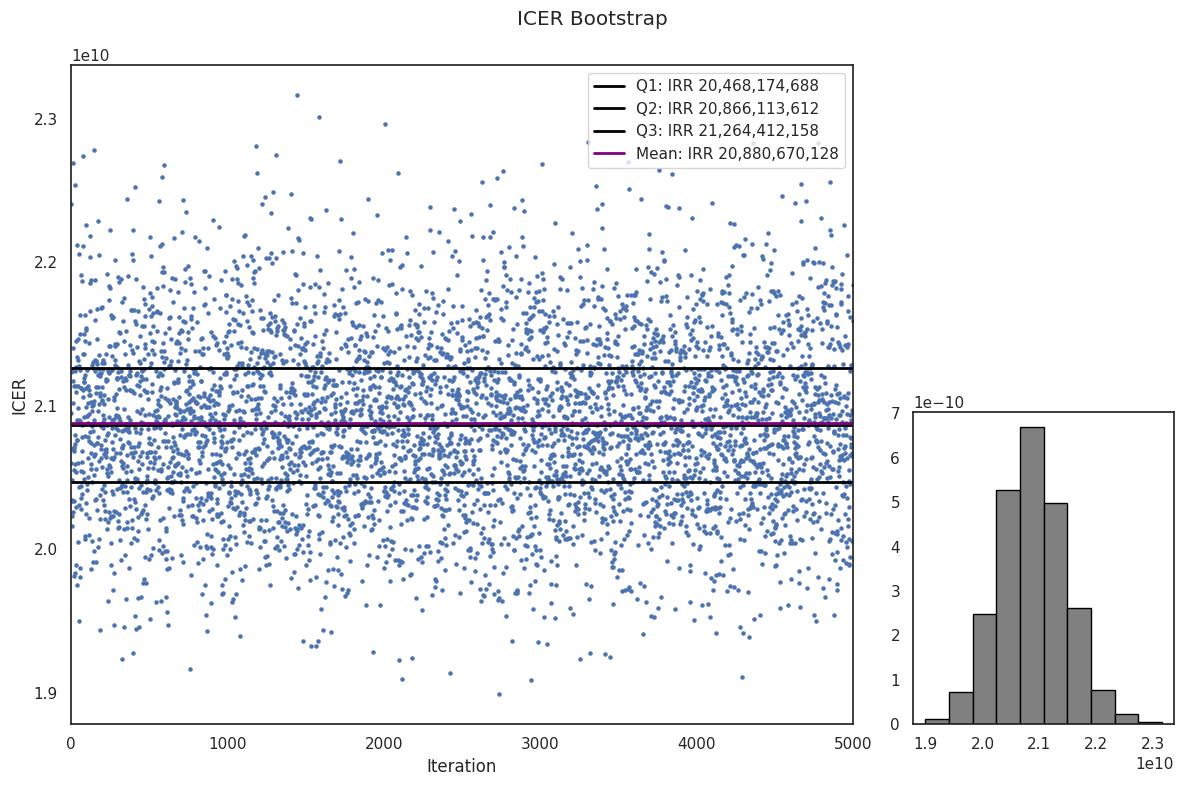

In [38]:
from matplotlib.gridspec import GridSpec

# ---- Plots Configs ----
sns.set_theme(style="white")
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))
scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[-1, -1])

# ---- PLOTS ----
X = [i for i in range(len(BOOTSTRAP_ICERS))]
scatter.scatter(X, BOOTSTRAP_ICERS, s=5)
hist.hist(BOOTSTRAP_ICERS, color="gray", density=True, edgecolor="black")


BQ1 = np.percentile(BOOTSTRAP_ICERS, 25).astype(float)
BQ2 = np.percentile(BOOTSTRAP_ICERS, 50).astype(float)
BQ3 = np.percentile(BOOTSTRAP_ICERS, 75).astype(float)
BOOTSTRAP_MEAN_ICER = np.mean(BOOTSTRAP_ICERS)

scatter.axhline(BQ1, color="black", linewidth=2, label=f"Q1: IRR {round(BQ1):,}")
scatter.axhline(BQ2, color="black", linewidth=2, label=f"Q2: IRR {round(BQ2):,}")
scatter.axhline(BQ3, color="black", linewidth=2, label=f"Q3: IRR {round(BQ3):,}")
scatter.axhline(
    float(BOOTSTRAP_MEAN_ICER),
    color="purple",
    linewidth=2,
    label=f"Mean: IRR {round(BOOTSTRAP_MEAN_ICER):,}",
)
scatter.set_xlim(left=0, right=len(BOOTSTRAP_ICERS))
scatter.set_ylabel("ICER")
scatter.set_xlabel("Iteration")
scatter.legend()
fig.suptitle("ICER Bootstrap")
fig.tight_layout()

logger.info(f"Median (IQR): IRR {round(BOOTSTRAP_MEAN_ICER):,} ({round(BQ3 - BQ1):,})")

INFO: Willingness to pay Threshold: IRR 1,800,000,000


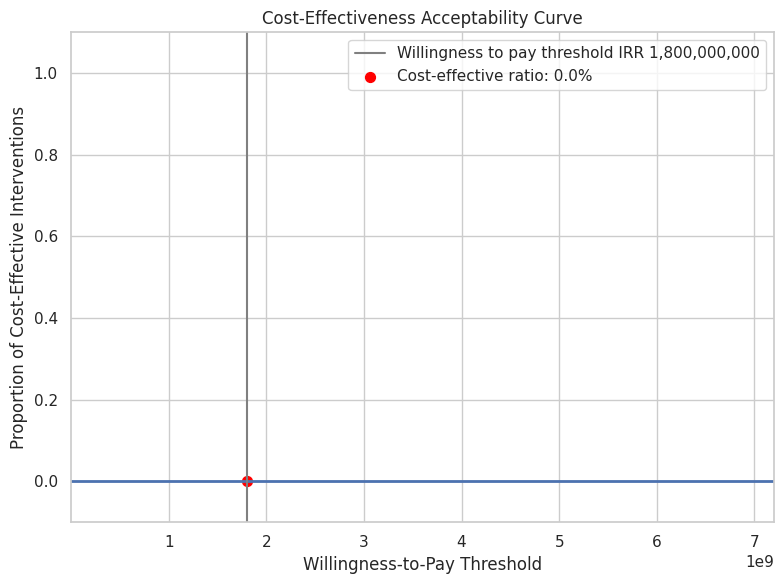

In [39]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 4
logger.info(
    f"Willingness to pay Threshold: {constants.MODEL_CURRENCY.upper()} {constants.WTP_THRESHOLD:,}"
)
X = np.linspace(start=0, stop=max_threshold, num=1000)
Y = []

for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(BOOTSTRAP_ICERS <= threshold)
    ratio = cost_effective_count / len(BOOTSTRAP_ICERS)
    Y.append(ratio)

below_threshold_icers = np.array(BOOTSTRAP_ICERS) <= constants.WTP_THRESHOLD
cost_effective_ratio = np.sum(below_threshold_icers / len(BOOTSTRAP_ICERS))

# Plot Acceptability Curve
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"Willingness to pay threshold {constants.MODEL_CURRENCY.upper()} {round(constants.WTP_THRESHOLD):,}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=cost_effective_ratio,
    color="red",
    s=50,
    label=f"Cost-effective ratio: {round(cost_effective_ratio, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(12000, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

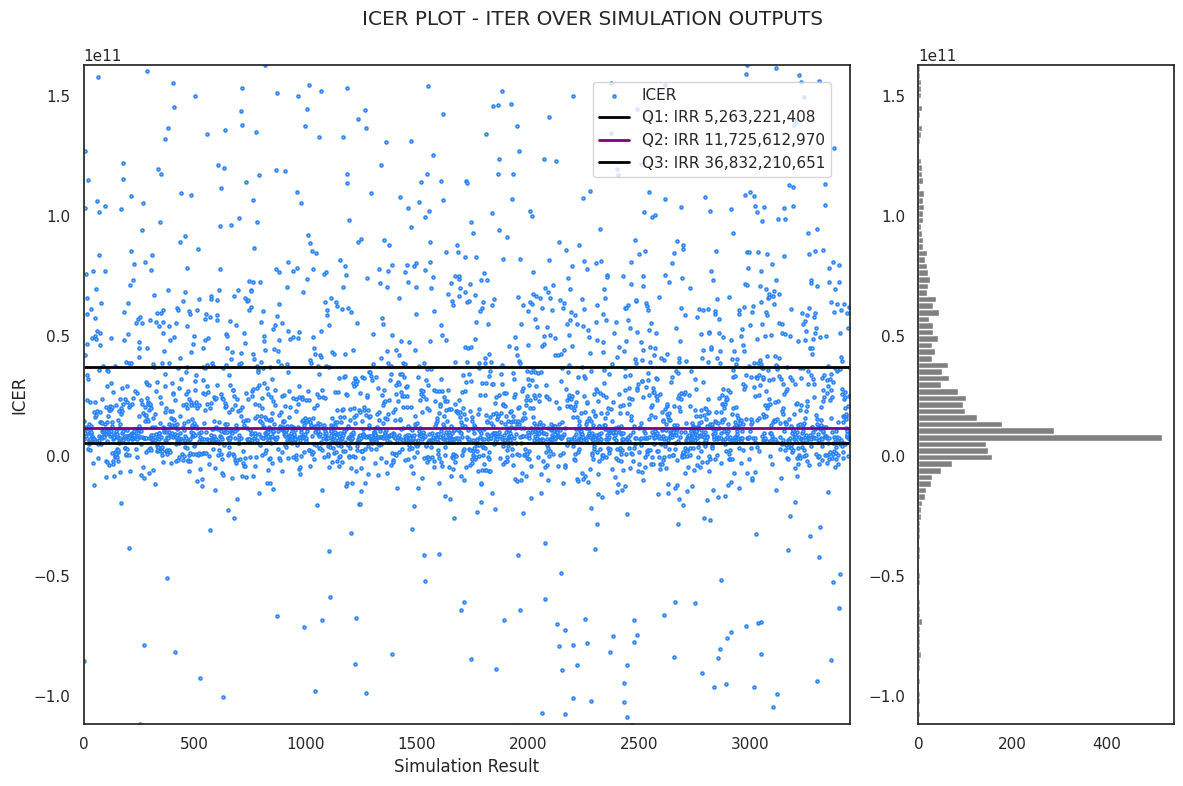

In [40]:
# sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
sns.set_theme(style="white")
DC_SERIES = prophylaxis_df.factor_costs - on_demand_df.factor_costs
DQ_SERIES = prophylaxis_df.qaly - on_demand_df.qaly
# Avoid zero-division error
valid_mask = np.isfinite(DQ_SERIES) & np.isfinite(DC_SERIES) & (DQ_SERIES != 0)
ICERS_PER_SIMULATION = DC_SERIES[valid_mask] / DQ_SERIES[valid_mask]

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[:, -1])

scatter.scatter(
    x=[i for i in range(len(ICERS_PER_SIMULATION))],
    y=ICERS_PER_SIMULATION,
    s=5,
    color="#88C6FF",
    edgecolors="#237FF8",
)
scatter.set_ylabel("ICER")
scatter.set_xlabel("Simulation Result")

BQ1 = np.percentile(ICERS_PER_SIMULATION, 25).astype(float)
BQ2 = np.percentile(ICERS_PER_SIMULATION, 50).astype(float)
BQ3 = np.percentile(ICERS_PER_SIMULATION, 75).astype(float)

P5 = np.percentile(ICERS_PER_SIMULATION, 5).astype(float)
P95 = np.percentile(ICERS_PER_SIMULATION, 95).astype(float)
TRUNC_ICERS = ICERS_PER_SIMULATION[
    (ICERS_PER_SIMULATION >= P5) & (ICERS_PER_SIMULATION <= P95)
]
hist.hist(TRUNC_ICERS, bins=100, color="gray", orientation="horizontal")
hist.set_ylim(bottom=P5, top=P95)

scatter.axhline(BQ1, color="black", linewidth=2)
scatter.axhline(BQ2, color="purple", linewidth=2)
scatter.axhline(BQ3, color="black", linewidth=2)
scatter.set_xlim(left=0, right=ICERS_PER_SIMULATION.shape[0])
scatter.set_ylim(bottom=P5, top=P95)
fig.suptitle("ICER plot - iter over simulation outputs".upper())
fig.legend(
    [
        "ICER",
        f"Q1: {constants.MODEL_CURRENCY.upper()} {int(BQ1):,}",
        f"Q2: {constants.MODEL_CURRENCY.upper()} {int(BQ2):,}",
        f"Q3: {constants.MODEL_CURRENCY.upper()} {int(BQ3):,}",
    ],
    loc="upper center",
    bbox_to_anchor=(0.60, 0.90),
)
fig.tight_layout()

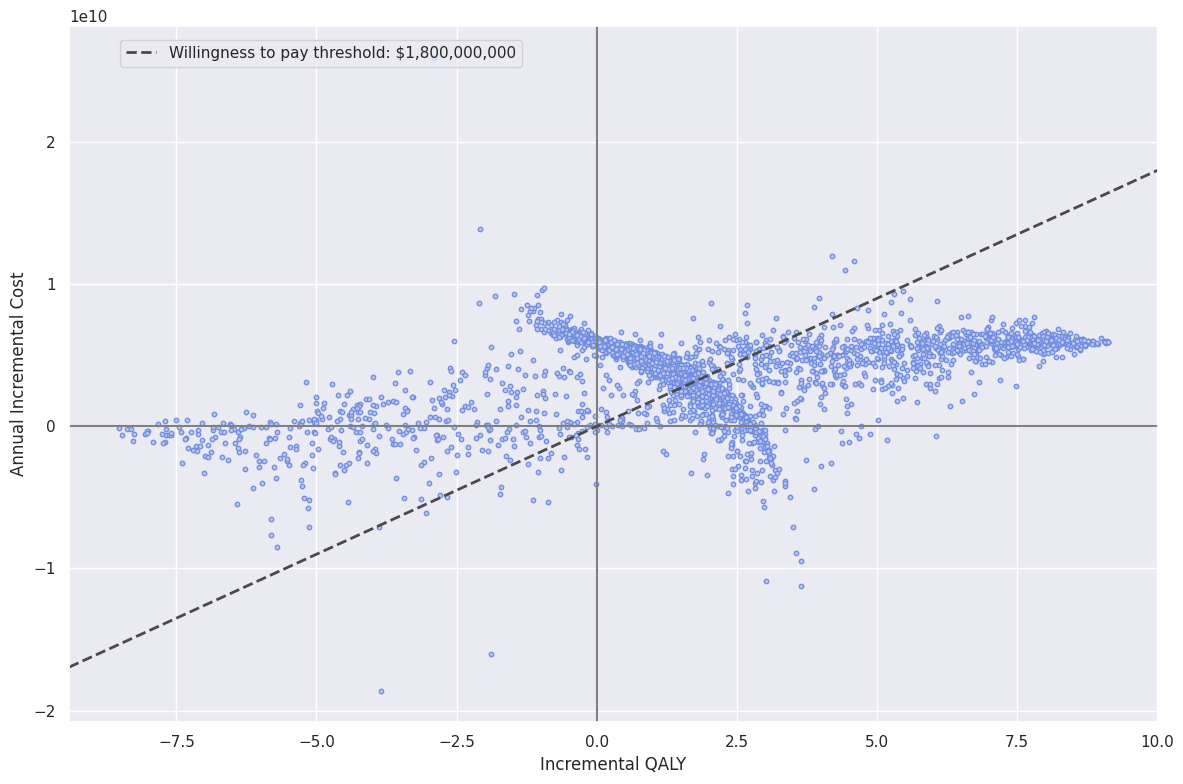

In [41]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(DQ_SERIES, per_year(DC_SERIES), s=10, edgecolor="#738EE0", color="#BACAED")
ax.set_xlabel("Incremental QALY")
ax.set_ylabel("Annual Incremental Cost")
ax.axvline(x=0, color="gray")
ax.axhline(y=0, color="gray")
ax.axline(
    (0, 0),
    slope=constants.WTP_THRESHOLD,
    color="#4A4A4A",
    linestyle="--",
    linewidth=2,
    label=f"Willingness to pay threshold: ${round(constants.WTP_THRESHOLD):,}",
)
fig.legend(loc="upper left", bbox_to_anchor=(0.10, 0.95))
fig.tight_layout()

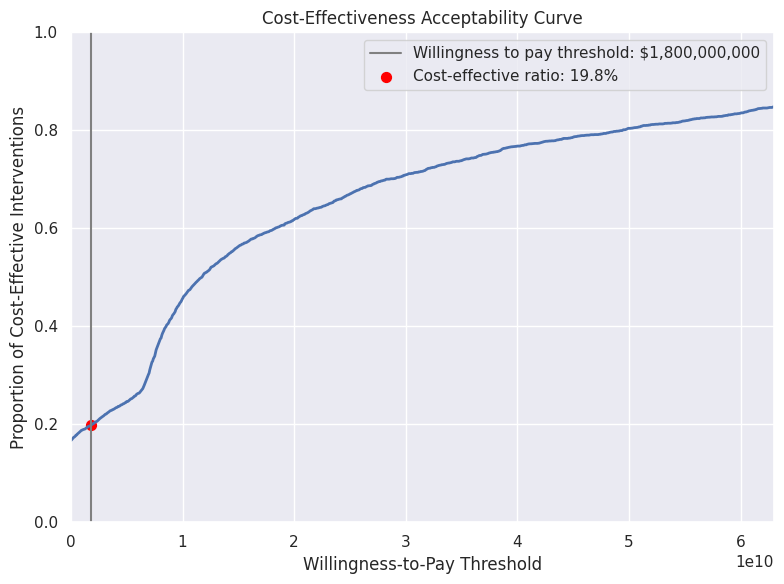

In [42]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 35
X = np.linspace(start=-5000, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS_PER_SIMULATION <= threshold)
    ratio = cost_effective_count / len(ICERS_PER_SIMULATION)
    Y.append(ratio)

# Point
cost_effective_count = np.sum(ICERS_PER_SIMULATION <= constants.WTP_THRESHOLD)
cost_effective_ratio = cost_effective_count / len(ICERS_PER_SIMULATION)

# Plot Acceptability Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"Willingness to pay threshold: ${round(constants.WTP_THRESHOLD):,}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=cost_effective_ratio,
    color="red",
    s=50,
    label=f"Cost-effective ratio: {round(cost_effective_ratio * 100, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(-5000, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

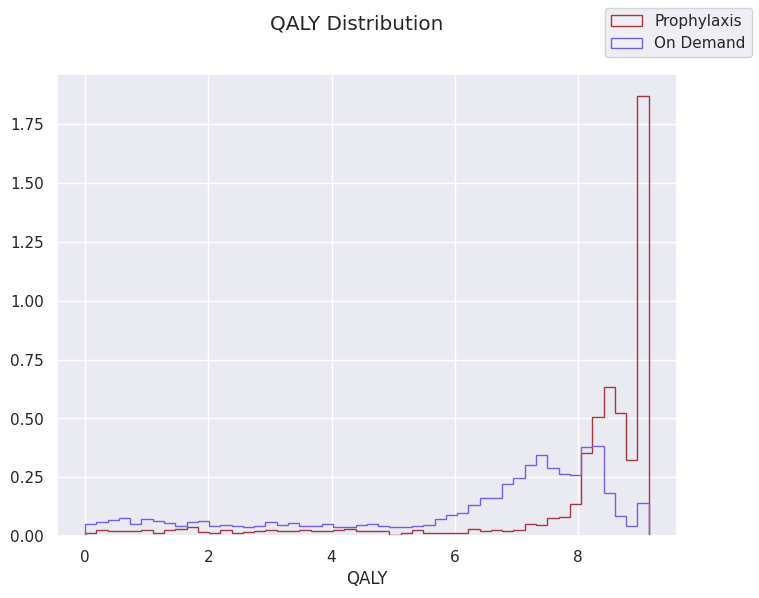

In [43]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    x=[on_demand_df.qaly, prophylaxis_df.qaly],
    bins=50,
    histtype="step",
    stacked=False,
    color=["#765EDF", "#A13A3A"],
    label=["On Demand", "Prophylaxis"],
    density=True,
)
ax.set_xlabel("QALY")
fig.suptitle("QALY Distribution")
fig.legend()

Text(0.5, 0.98, 'Costs Distribution')

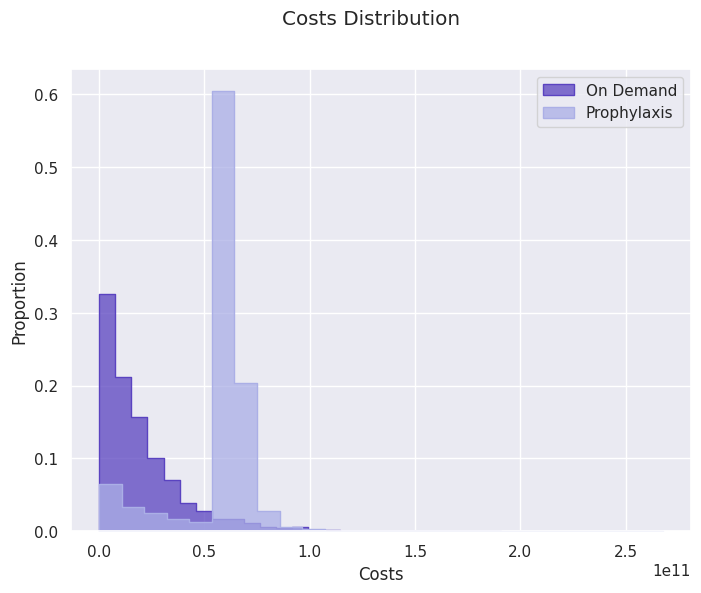

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    data=on_demand_df,
    x="factor_costs",
    bins=25,
    stat="probability",
    color="#5A43C0",
    label="On Demand",
    element="step",
    ax=ax,
)
sns.histplot(
    data=prophylaxis_df,
    x="factor_costs",
    bins=25,
    stat="probability",
    color="#ABAFE6",
    label="Prophylaxis",
    element="step",
    ax=ax,
)
ax.set_xlabel("Costs")
ax.set_ylabel("Proportion")
ax.legend()
fig.suptitle("Costs Distribution")

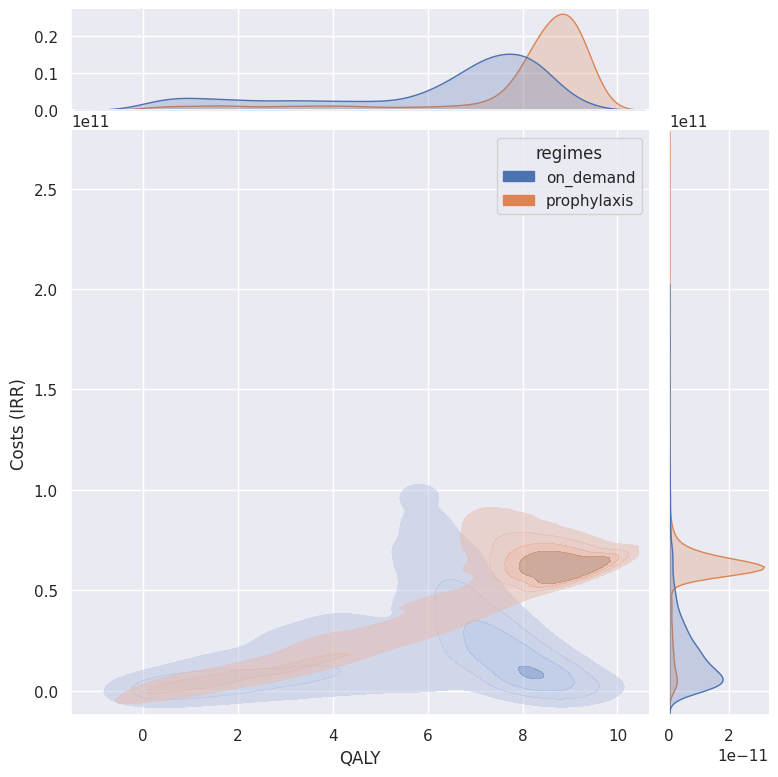

In [45]:
jg = sns.jointplot(
    data=df,
    x="qaly",
    y="factor_costs",
    hue="regimes",
    kind="kde",
    bw_adjust=0.8,
    height=8,
    palette=sns.color_palette("deep", 2),
    marginal_ticks=True,
    fill=True,
    alpha=0.5,
    levels=[0.04, 0.25, 0.5, 0.75, 1],
)
jg.set_axis_labels("QALY", "Costs (IRR)")

In [46]:
# Acceptable
od_acceptable = on_demand_df[on_demand_df.qaly > 50]
logger.info(
    f"""
    [Acceptable outcomes]
    On Demand patients had annual bleeding rate median: {f2(od_acceptable.input_abr.mean())} ({f2(od_acceptable.input_abr.std())}) got acceptable quality adjusted life year gains
    """
)

INFO: 
    [Acceptable outcomes]
    On Demand patients had annual bleeding rate median: nan (nan) got acceptable quality adjusted life year gains
    


INFO: ---- Priorities ----
INFO: Cluster 0: (4, 12)
INFO: Cluster 1: (50, 100)
INFO: Cluster 2: (37, 57)
INFO: Cluster 3: (0, 3)
INFO: Cluster 4: (13, 22)
INFO: Cluster 5: (23, 36)
INFO: ====================
INFO: Best fit model was lognormal
INFO: Lognormal: a * exp(-b * log(x + c)) + d ---> a: 102168328874.93, b: 0.674, c: 5.0, d: -4254759698.41


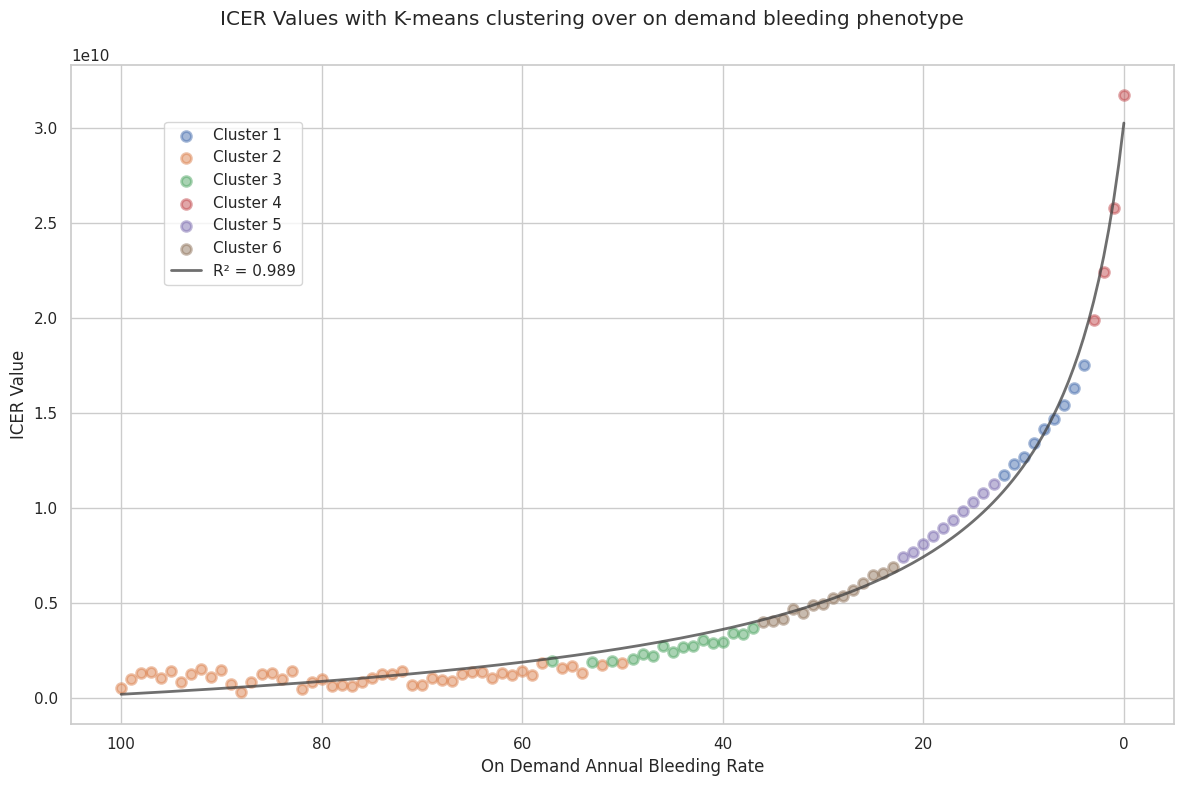

In [47]:
from scipy.cluster.vq import kmeans, vq
from scipy.optimize import curve_fit


# ---- Sampling and selection ----
icer_selected = {}
max_n = min(100, int(on_demand_df.input_abr.max()))

for n in np.arange(0, max_n + 1):  # inclusive
    # Select on-demand patients with input_abr >= n
    od_selection = on_demand_df[on_demand_df.input_abr >= n]

    if len(od_selection) == 0:
        icer_selected[n] = np.nan  # No patients, skip
        continue

    # Determine how many we can sample from prophylaxis (can't exceed its size)
    max_possible_sample = len(prophylaxis_df)
    sample_size = min(len(od_selection), max_possible_sample)

    if sample_size == 0:
        icer_selected[n] = np.nan
        continue

    # Sample from prophylaxis without replacement
    pro_selection = prophylaxis_df.sample(n=sample_size, replace=False)

    # Calculate differences
    dcs = pro_selection.factor_costs.sum() - od_selection.factor_costs.sum()
    dqs = pro_selection.qaly.sum() - od_selection.qaly.sum()

    # Avoid division by zero or near-zero
    if abs(dqs) < 1e-6:
        selected_icer = np.inf if dcs > 0 else -np.inf
    else:
        selected_icer = dcs / dqs

    icer_selected[n] = selected_icer

# icer_selected = {}
# for n in np.arange(0, min(100, on_demand_df.input_abr.max())):
#     od_selection = on_demand_df[on_demand_df.input_abr >= n]
#     pro_selection = prophylaxis_df.sample(len(od_selection))
#     dcs = pro_selection.factor_costs.sum() - od_selection.factor_costs.sum()
#     dqs = pro_selection.qaly.sum() - od_selection.qaly.sum()
#     selected_icer = dcs / dqs
#     icer_selected[n] = selected_icer

# ---- Clustering ----
k_value = 6
icer_values = np.array(list(icer_selected.values()))
centroids, distortion = kmeans(icer_values, k_value)

cluster_assignments, _ = vq(icer_values, centroids)
x_values = np.array(list(icer_selected.keys()))

# Filter out any NaN or infinite values for curve fitting
valid_mask = np.isfinite(icer_values)
x_fit = x_values[valid_mask]
y_fit = icer_values[valid_mask]

# Initialize variables
fit_successful = False
best_fit_type = None
best_r_squared = -np.inf
fit_results = {}


# Exponential fit
def exponential_func(x, a, b, c):
    """Exponential function: a * exp(b * x) + c"""
    return a * np.exp(b * x) + c


# Lognormal fit (modified)
def lognormal_func(x, a, b, c, d):
    """
    Lognormal model: a * exp(-b * log(x + c)) + d
    This creates a smooth decay that resembles lognormal behavior but works for any y-range
    """
    log_term = np.log(np.maximum(x + c, 0.1))
    return a * np.exp(-b * log_term) + d


# Try different fitting methods
x_fit_range = np.linspace(min(x_values), max(x_values), 200)
# 1. Exponential fit
try:
    if len(x_fit) > 3:
        # Try different initial guesses
        initial_guesses = [
            [np.mean(y_fit), 0.01, np.min(y_fit)],  # Small growth
            [np.mean(y_fit), -0.01, np.min(y_fit)],  # Decay
            [1, 0.1, np.mean(y_fit)],  # Original
        ]

        best_exp_r2 = -np.inf
        best_exp_params = None

        # bounds
        bounds = ([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf])
        # b bounded to negative (decay only)
        decay_bounds = ([-np.inf, -10, -np.inf], [np.inf, 0, np.inf])
        for p0 in initial_guesses:
            try:
                params, _ = curve_fit(
                    exponential_func,
                    x_fit,
                    y_fit,
                    p0=p0,
                    maxfev=10000,
                    bounds=decay_bounds,
                )
                y_pred = exponential_func(x_fit, *params)
                ss_res = np.sum((y_fit - y_pred) ** 2)
                ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                if r2 > best_exp_r2:
                    best_exp_r2 = r2
                    best_exp_params = params

            except Exception:
                continue

        if best_exp_params is not None:
            fit_results["exponential"] = {
                "params": best_exp_params,
                "r_squared": best_exp_r2,
                "curve": exponential_func(x_fit_range, *best_exp_params),
            }
            if best_exp_r2 > best_r_squared:
                best_r_squared = best_exp_r2
                best_fit_type = "exponential"

except Exception as e:
    logger.error(f"Exponential fit failed: {e}")

# 2. Lognormal fit
try:
    if len(x_fit) > 3:
        # Initial guesses for lognormal model
        initial_guesses = [
            [np.max(y_fit), 0.5, 1.0, np.min(y_fit)],  # Standard decay
            [np.max(y_fit) * 0.5, 0.3, 0.5, np.min(y_fit)],  # Slower decay
            [np.max(y_fit), 1.0, 2.0, np.min(y_fit)],  # Faster decay
        ]

        best_lognorm_r2 = -np.inf
        best_lognorm_params = None

        for p0 in initial_guesses:
            try:
                params, _ = curve_fit(
                    lognormal_func,
                    x_fit,
                    y_fit,
                    p0=p0,
                    maxfev=10000,
                    bounds=(
                        [0.01, 0.01, 0.01, -np.inf],
                        [np.inf, np.inf, np.inf, np.inf],
                    ),
                )
                y_pred = lognormal_func(x_fit, *params)
                ss_res = np.sum((y_fit - y_pred) ** 2)
                ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                if r2 > best_lognorm_r2:
                    best_lognorm_r2 = r2
                    best_lognorm_params = params

            except Exception:
                continue

        if best_lognorm_params is not None:
            lognorm_curve = lognormal_func(x_fit_range, *best_lognorm_params)
            fit_results["lognormal"] = {
                "params": best_lognorm_params,
                "r_squared": best_lognorm_r2,
                "curve": lognorm_curve,
                "label": f"Lognormal-inspired (R²={best_lognorm_r2:.3f})",
            }
            if best_lognorm_r2 > best_r_squared:
                best_r_squared = best_lognorm_r2
                best_fit_type = "lognormal"

except Exception as e:
    logger.error(f"Lognormal-inspired fit failed: {e}")


# --- Plotting Section ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

logger.info("---- Priorities ----")
for cluster_id in range(k_value):
    mask = cluster_assignments == cluster_id
    logger.info(
        f"Cluster {cluster_id}: ({np.min(x_values[mask])}, {np.max(x_values[mask])})"
    )
    ax.scatter(
        x=np.array(x_values)[mask],  # type: ignore
        y=icer_values[mask],
        alpha=0.5,
        s=50,
        label=f"Cluster {cluster_id + 1}",
        linewidth=2,
    )

logger.info("=" * 20)
# Plot best fit
fit_successful = len(fit_results) > 0
if fit_successful and best_fit_type in fit_results:
    best_result = fit_results[best_fit_type]
    logger.info("Best fit model was {}".format(best_fit_type))
    if best_fit_type == "lognormal":
        params = best_result["params"]
        logger.info(
            f"Lognormal: a * exp(-b * log(x + c)) + d ---> a: {params[0]:.2f}, b: {params[1]:.3f}, c: {params[2]:.1f}, d: {params[3]:.2f}"
        )
    elif best_fit_type == "exponential":
        params = best_result["params"]
        logger.info(
            f"Exponential: a(e)**(bx) + c ---> a: {f2(params[0])}, b: {f2(params[1])}, c: {f2(params[2])}"
        )
    ax.plot(
        x_fit_range,
        best_result["curve"],
        color="#3F3F3F",
        alpha=0.75,
        linewidth=2,
        label=f"R² = {best_result['r_squared']:.3f}",
    )

ax.set_xlabel("On Demand Annual Bleeding Rate")
ax.set_ylabel("ICER Value")
ax.invert_xaxis()
fig.suptitle("ICER Values with K-means clustering over on demand bleeding phenotype")
fig.legend(
    loc="upper right",
    bbox_to_anchor=(0.265, 0.85),
)
fig.tight_layout()

In [48]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ ]
# Onset of arthropathy [ ]
# Number of treated bleeds [ ]
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]